In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=14)
plt.rc('ytick', labelsize=14)

In [ ]:
from sklearn.datasets import load_iris

iris = load_iris()

In [ ]:
X = iris['data']
y = iris['target']
X.shape, y.shape

((150, 4), (150,))

In [ ]:
from sklearn.model_selection import train_test_split

#randomly put 20% of the data in test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1)

In [ ]:
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

X_train_norm = (X_train - np.mean(X_train)) / np.std(X_train)
X_train_norm = torch.from_numpy(X_train_norm).float()
y_train = torch.from_numpy(y_train)

train_ds = TensorDataset(X_train_norm, y_train)

torch.manual_seed(1)
batch_size = 2
train_dl = DataLoader(train_ds, batch_size, shuffle=True)

In [ ]:
import torch.nn as nn

class Model(nn.Module):
    def __init__(self, input_size, hidden_size1, hidden_size2, output_size):
        super().__init__()
        self.layer1 = nn.Linear(input_size, hidden_size1)
        self.layer2 = nn.Linear(hidden_size1, hidden_size2)
        self.layer3 = nn.Linear(hidden_size2, output_size)

    def forward(self, x):
        x = self.layer1(x)
        x = nn.Tanh()(x)
        x = self.layer2(x)
        x = nn.Tanh()(x)
        x = self.layer3(x)
        x = nn.Softmax(dim=1)(x) #This one is for applying softmax operation
        return x


In [ ]:
import torch
import torch.nn as nn

model = nn.Sequential(
    nn.Linear(4, 16),
    nn.ReLU(),
    nn.Linear(16, 3)
)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

num_epochs = 10000
loss_hist = [0.0] * num_epochs
accuracy_hist = [0.0] * num_epochs

for epoch in range(num_epochs):

    model.train()

    for x_batch, y_batch in train_dl:

        y_batch = y_batch.long()

        # forward
        pred = model(x_batch)
        loss = loss_fn(pred, y_batch)

        # backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


        loss_hist[epoch] += loss.item() * x_batch.size(0)

        with torch.no_grad():
            preds = torch.argmax(pred, dim=1)
            accuracy_hist[epoch] += (preds == y_batch).sum().item()

    # normalize
    loss_hist[epoch] /= len(train_dl.dataset)
    accuracy_hist[epoch] /= len(train_dl.dataset)


    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, Train Loss = {loss_hist[epoch]:.4f}, "
              f"Accuracy = {accuracy_hist[epoch]:.4f}")

Epoch 0, Train Loss = 1.0436, Accuracy = 0.5417
Epoch 1000, Train Loss = 0.0553, Accuracy = 0.9833
Epoch 2000, Train Loss = 0.0527, Accuracy = 0.9750
Epoch 3000, Train Loss = 0.0489, Accuracy = 0.9833
Epoch 4000, Train Loss = 0.0433, Accuracy = 0.9750
Epoch 5000, Train Loss = 0.0400, Accuracy = 0.9750
Epoch 6000, Train Loss = 0.0420, Accuracy = 0.9833
Epoch 7000, Train Loss = 0.0417, Accuracy = 0.9833
Epoch 8000, Train Loss = 0.0362, Accuracy = 0.9833
Epoch 9000, Train Loss = 0.0410, Accuracy = 0.9833


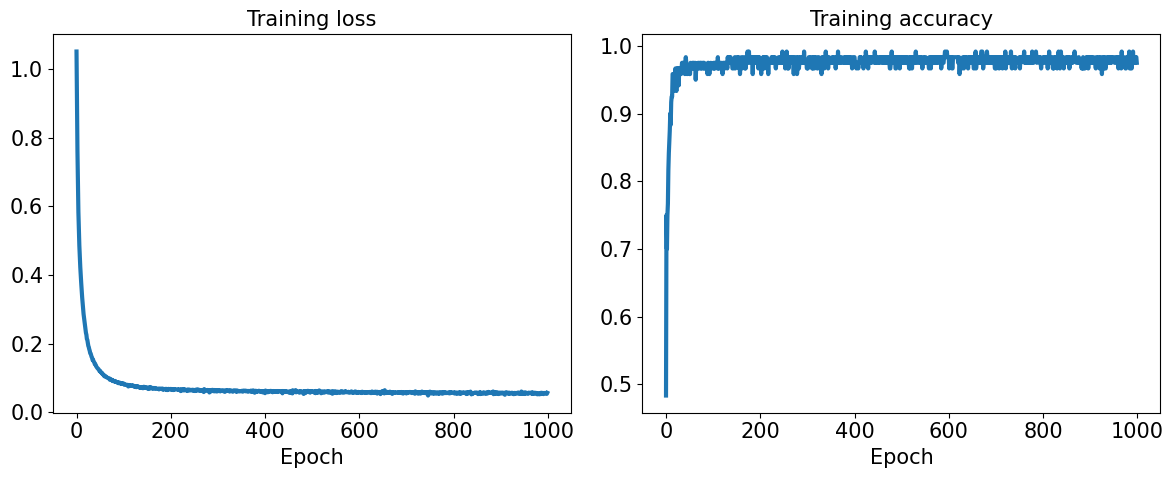

In [ ]:
fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(1, 2, 1)
ax.plot(loss_hist, lw=3)
ax.set_title('Training loss', size=15)
ax.set_xlabel('Epoch', size=15)
ax.tick_params(axis='both', which='major', labelsize=15)

ax = fig.add_subplot(1, 2, 2)
ax.plot(accuracy_hist, lw=3)
ax.set_title('Training accuracy', size=15)
ax.set_xlabel('Epoch', size=15)
ax.tick_params(axis='both', which='major', labelsize=15)
plt.tight_layout()


In [ ]:
X_test_norm = (X_test - np.mean(X_train)) / np.std(X_train)
X_test_norm = torch.from_numpy(X_test_norm).float()
y_test = torch.from_numpy(y_test)
pred_test = model(X_test_norm)

correct = (torch.argmax(pred_test, dim=1) == y_test).float()
accuracy = correct.mean()

print(f'Test Acc.: {accuracy:.4f}')

Test Acc.: 1.0000


In [ ]:
path = 'iris_classifier.pt'
torch.save(model, path)

In [ ]:
model_new = torch.load(path)
model_new.eval()

UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL torch.nn.modules.container.Sequential was not an allowed global by default. Please use `torch.serialization.add_safe_globals([torch.nn.modules.container.Sequential])` or the `torch.serialization.safe_globals([torch.nn.modules.container.Sequential])` context manager to allowlist this global if you trust this class/function.

Check the documentation